**Predicting Hotel Reservation Cancellations**

In [1]:
#import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, confusion_matrix,precision_score,recall_score

from imblearn.over_sampling import SMOTE

import joblib

Loading the Dataset

In [ ]:
#loading the dataset
df = pd.read_csv("Hotel Reservations.csv")
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


**EDA (Exploratory Data Analysis) - Understanding the Dataset**

In [ ]:
#Shape(rows, columns)
df.shape

(36275, 19)

In [ ]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [ ]:
#Statistical Summary
df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [ ]:
#Checking for null values
df.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


The dataset does not contain any missing values.

This allows us to directly proceed with exploratory data analysis.

**Analyzing Target Variable (Booking Status)**

In [ ]:
df['booking_status'].value_counts()

,count
booking_status,
Not_Canceled,24390
Canceled,11885


In [ ]:
df['booking_status'].value_counts(normalize=True)*100

,proportion
booking_status,
Not_Canceled,67.236389
Canceled,32.763611


The dataset shows a moderate class imbalance, where the Not_Canceled class is roughly twice the size of the Canceled class.


**Understanding the data distribution**

In [ ]:
#distribution for room type
df['room_type_reserved'].value_counts()

,count
room_type_reserved,
Room_Type 1,28130
Room_Type 4,6057
Room_Type 6,966
Room_Type 2,692
Room_Type 5,265
Room_Type 7,158
Room_Type 3,7


This feature may influence cancellation behavior, as higher-priced or premium rooms might have different cancellation patterns.

In [ ]:
#distribution for market segment
df['market_segment_type'].value_counts()

,count
market_segment_type,
Online,23214
Offline,10528
Corporate,2017
Complementary,391
Aviation,125


Online segment has the highest number of bookings.

In [ ]:
#Chechking the repeated guests
df['repeated_guest'].value_counts()

,count
repeated_guest,
0,35345
1,930


The majority of customers are new guests (non-repeated), while a smaller portion are returning customers.

In [ ]:
#Distribution for type of meal plan
df['type_of_meal_plan'].value_counts()

,count
type_of_meal_plan,
Meal Plan 1,27835
Not Selected,5130
Meal Plan 2,3305
Meal Plan 3,5


Different meal plans are offered, with Meal PLan 1 being the most commonly selected.

Some customers opt for no meal plan.

In [ ]:
df['no_of_previous_cancellations'].value_counts()

,count
no_of_previous_cancellations,
0,35937
1,198
2,46
3,43
11,25
5,11
4,10
13,4
6,1


Majority of the guests do not have any previous cancellations as they are new customers

**EDA (Exploratory Data Analysis) – Visualizations**

*Booking Status Distribution*

- The dataset shows that non-canceled bookings are higher than canceled bookings, confirming a moderate class imbalance.

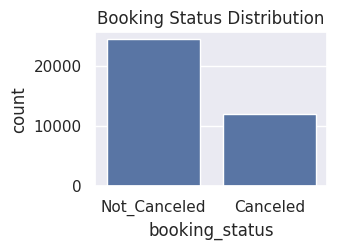

In [ ]:
plt.figure(figsize=(3,2))
sns.countplot(x='booking_status', data=df)
plt.title("Booking Status Distribution")
plt.show()

*Lead Time Analysis*

- Higher lead times are associated with increased cancellation probability.

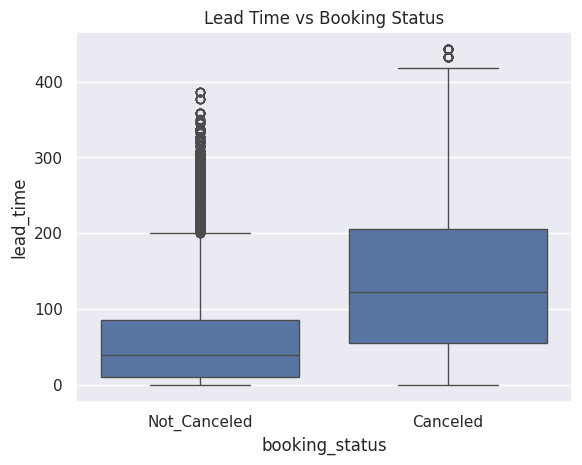

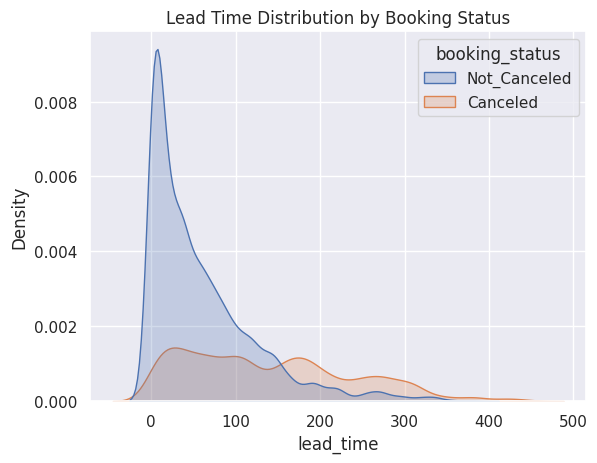

In [ ]:
sns.boxplot(x='booking_status', y='lead_time', data=df)
plt.title("Lead Time vs Booking Status")
plt.show()

sns.kdeplot(data=df, x="lead_time", hue="booking_status", fill=True)
plt.title("Lead Time Distribution by Booking Status")
plt.show()

*Price Analysis*

- Slightly higher-priced bookings show more cancellations.

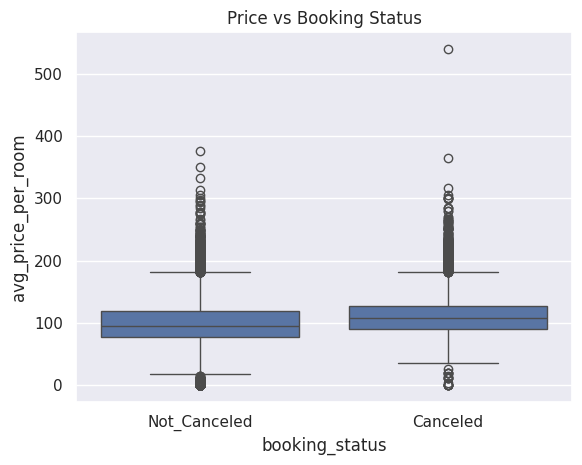

In [ ]:
sns.boxplot(x='booking_status', y='avg_price_per_room', data=df)
plt.title("Price vs Booking Status")
plt.show()

*Adults & Children Distribution*

- Majority of bookings involve 2 adults, which is the most common travel pattern.
- Bookings with children are fewer, but they show lower cancellation rates.


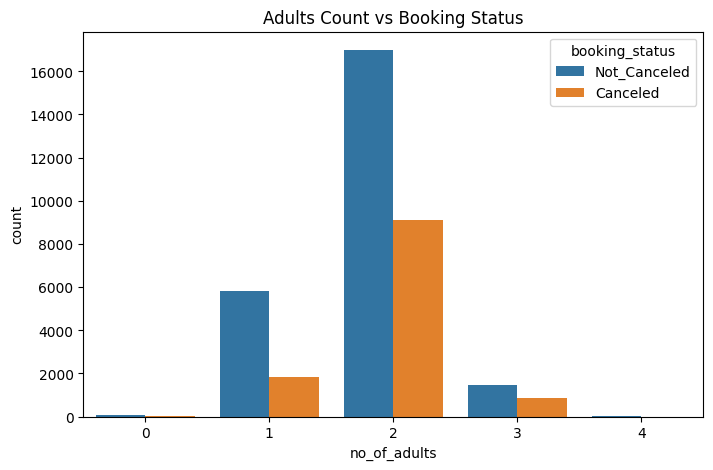

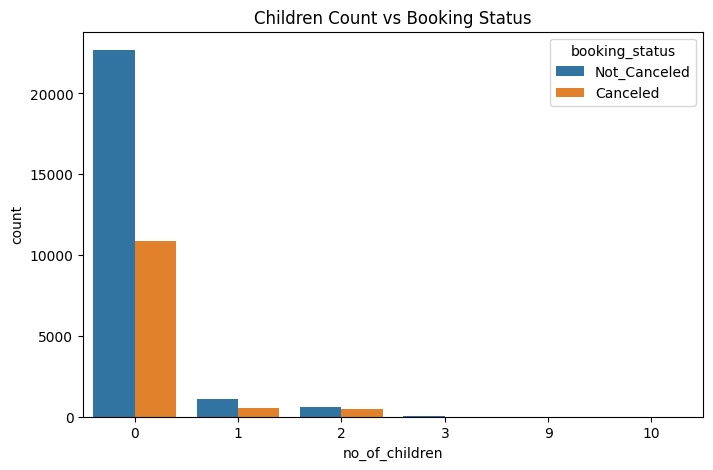

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='no_of_adults', hue='booking_status', data=df)
plt.title("Adults Count vs Booking Status")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='no_of_children', hue='booking_status', data=df)
plt.title("Children Count vs Booking Status")
plt.show()

*Weekday vs Weekend Stay & Cancellation*

*Weekend Nights vs Booking Status*

- Bookings with more weekend nights show a moderate increase in cancellations, possibly due to leisure travel plans being more flexible or prone to change.

- Short weekend stays are the most common.

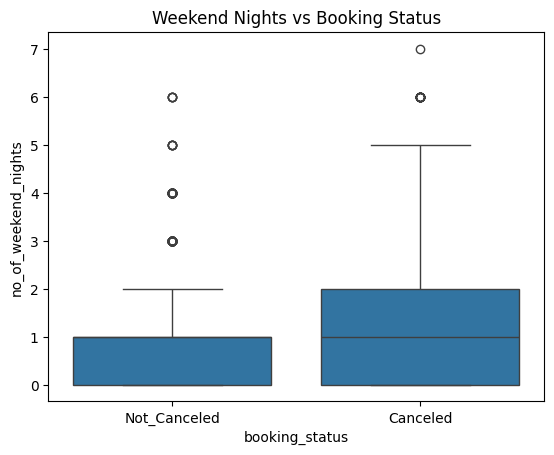

In [ ]:
sns.boxplot(x='booking_status', y='no_of_weekend_nights', data=df)
plt.title("Weekend Nights vs Booking Status")
plt.show()

*Weekday Nights vs Booking Status*

- Bookings with more weekday nights tend to have lower cancellation rates, indicating that business or work-related trips are more stable.

- Weekday-heavy bookings are generally more reliable compared to weekend-focused bookings.

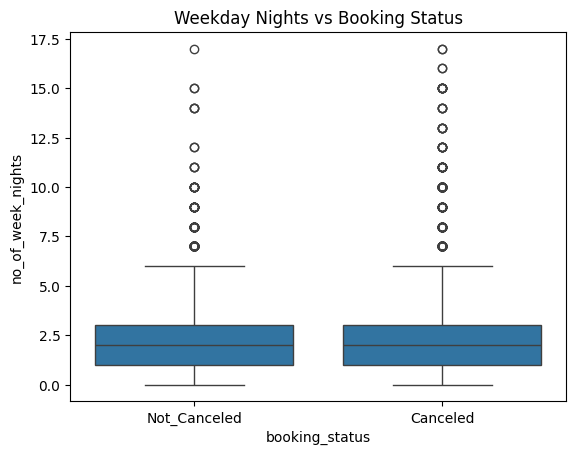

In [ ]:
sns.boxplot(x='booking_status', y='no_of_week_nights', data=df)
plt.title("Weekday Nights vs Booking Status")
plt.show()

*Weekday vs Weekend Distribution*

- Most bookings include 0–2 weekend nights, indicating short leisure trips.
- Weekday stays are more evenly distributed and show greater stability.
- Weekend-heavy bookings have slightly higher cancellation risk.

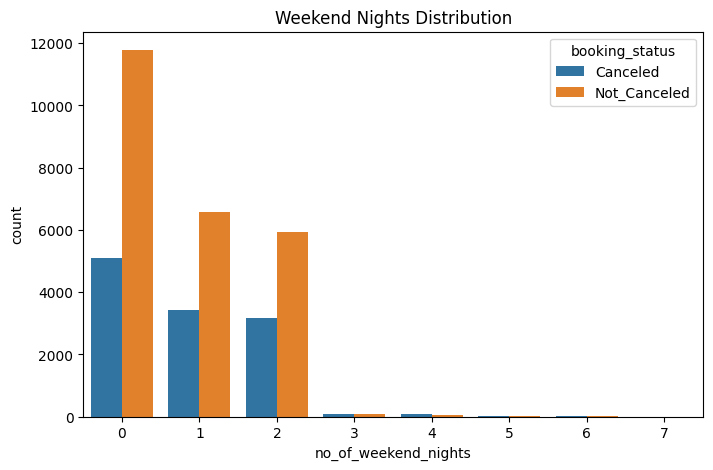

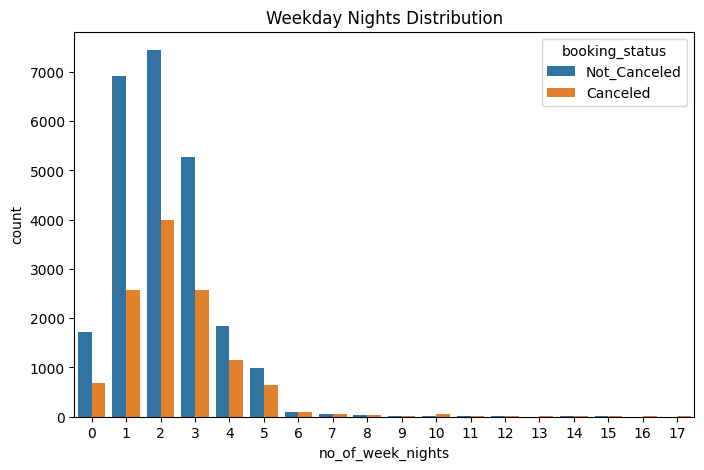

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='no_of_weekend_nights', hue='booking_status', data=df)
plt.title("Weekend Nights Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='no_of_week_nights', hue='booking_status', data=df)
plt.title("Weekday Nights Distribution")
plt.show()

*Market Segment & Cancellation*

- Online segment has the highest cancellations; corporate bookings are more stable.

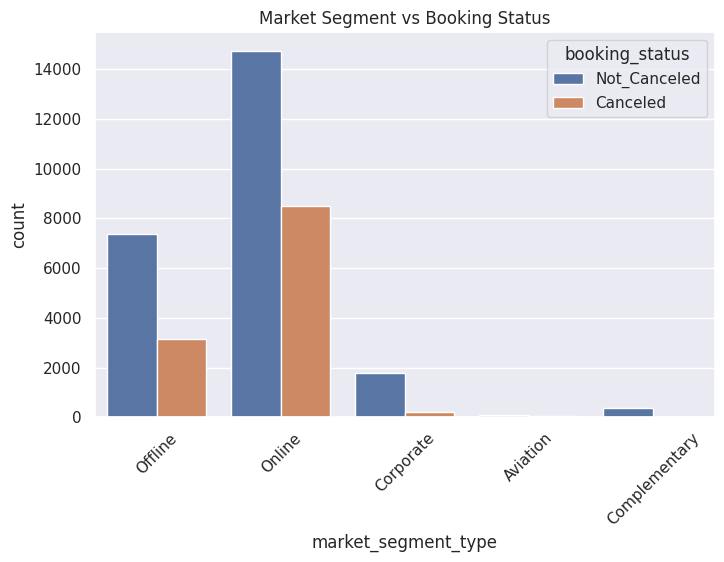

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='market_segment_type', hue='booking_status', data=df)
plt.xticks(rotation=45)
plt.title("Market Segment vs Booking Status")
plt.show()

*Meal Plan & Cancellation*

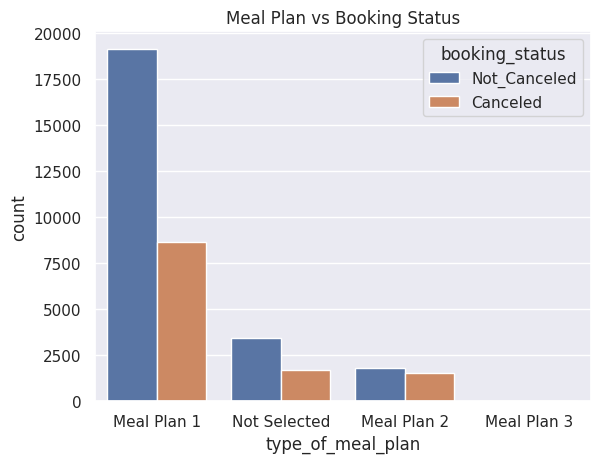

In [ ]:
sns.countplot(x='type_of_meal_plan', hue='booking_status', data=df)
plt.title("Meal Plan vs Booking Status")
plt.show()

*Room Type & Cancellation*



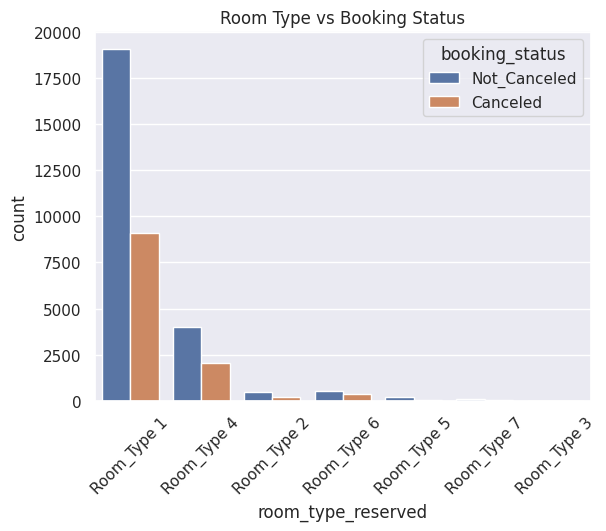

In [ ]:
sns.countplot(x='room_type_reserved', hue='booking_status', data=df)
plt.title("Room Type vs Booking Status")
plt.xticks(rotation=45)
plt.show()

*Repeated Guest & Cancellation*

- Repeated guests cancel less frequently.

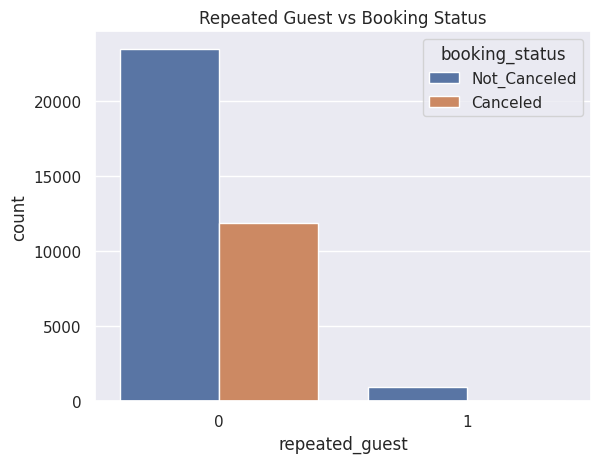

In [ ]:
sns.countplot(x='repeated_guest', hue='booking_status', data=df)
plt.title("Repeated Guest vs Booking Status")
plt.show()

*Feature Correlation Heatmap*

- Most features show low to moderate correlations,indicating limited multicollinearity.

- Repeated guest shows a moderate negative correlation with cancellation, meaning repeated guests are less likely to cancel.

- Number of previous cancellations and previous bookings not canceled have moderate positive correlations with cancellation, highlighting the importance of customer booking history.

- Average price per room has a weak positive correlation with cancellation.

- Features like lead time show weak correlation, but they remain important predictors.

- Overall, the heatmap suggests that multiple features contribute independently to the prediction task, justifying the use of multivariate models.

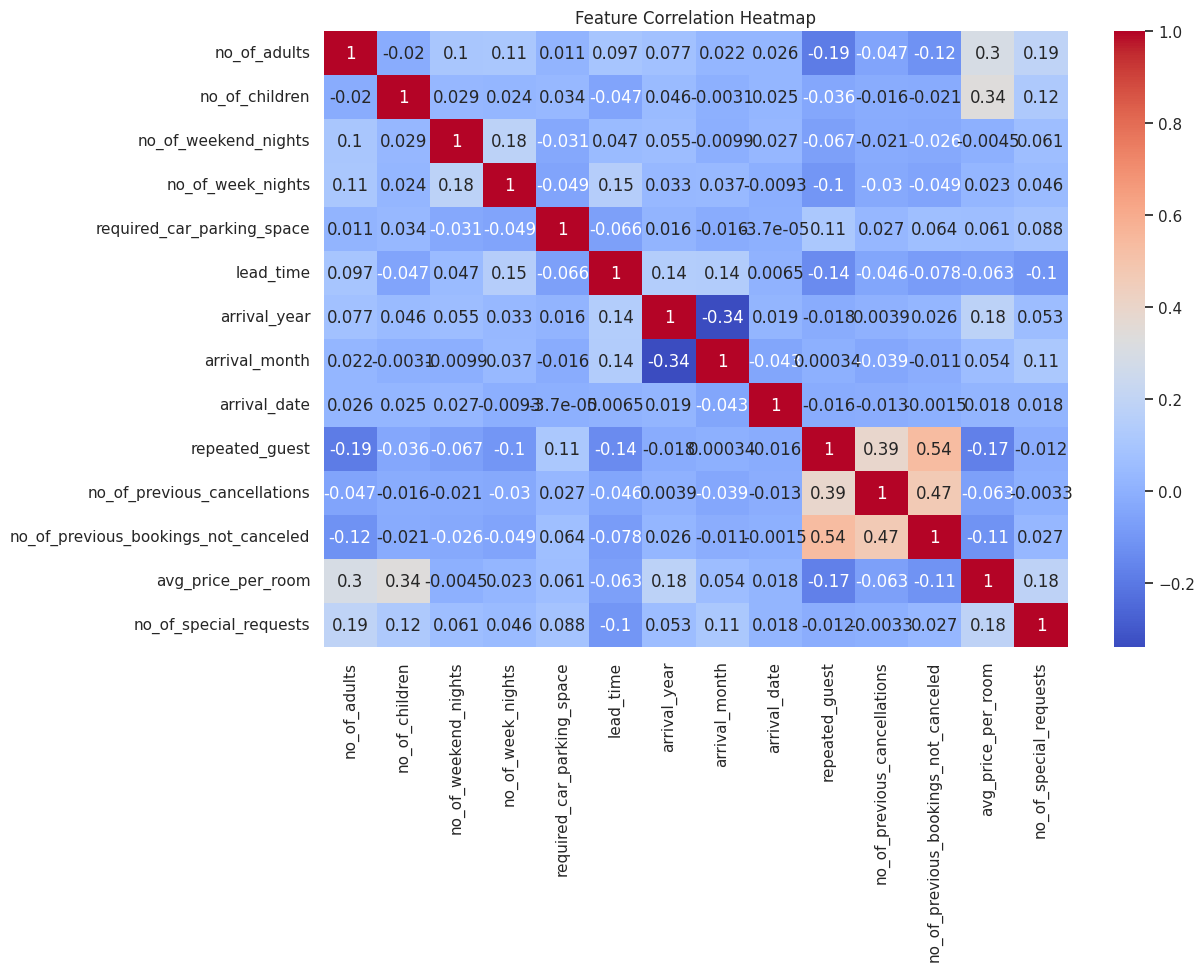

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

*Histogram of All Numerical Features*

- Features like lead_time are right-skewed, indicating long-tail bookings.

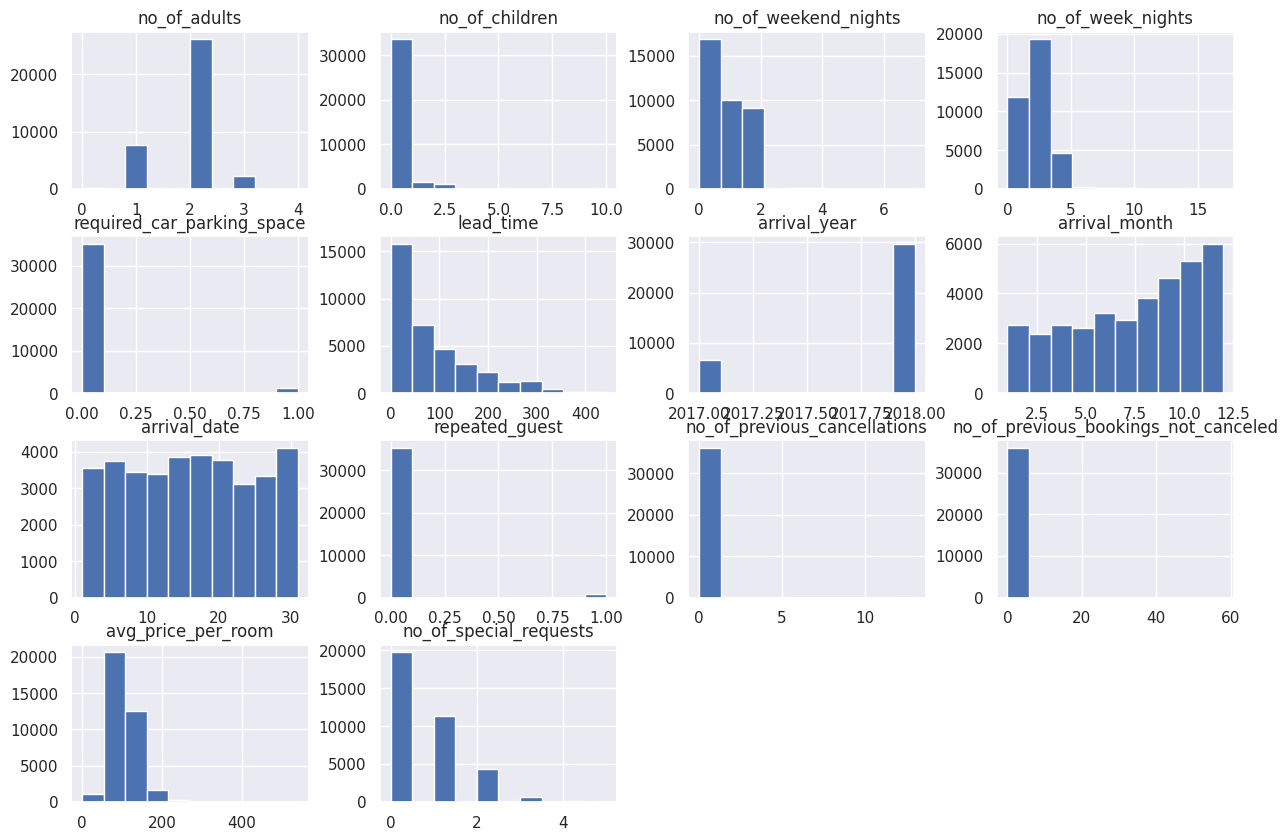

In [ ]:
df.hist(figsize=(15,10))
plt.show()

*Special Requests vs Booking Cancellation*

- Customers with more special requests are less likely to cancel.

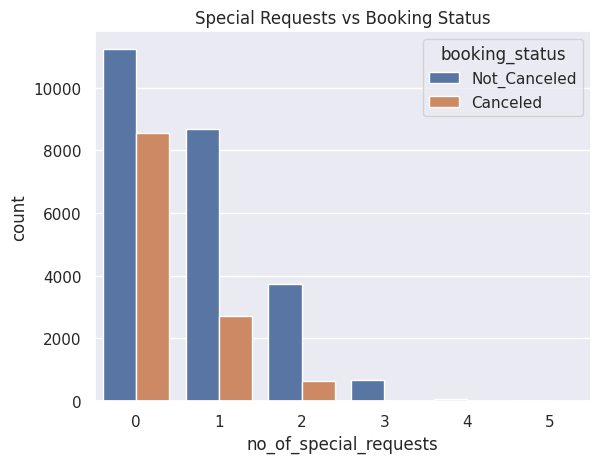

In [ ]:
sns.countplot(x='no_of_special_requests', hue='booking_status', data=df)
plt.title("Special Requests vs Booking Status")
plt.show()

*Creating box plots for every variable*

- Outliers are present in features like lead_time and avg_price_per_room.

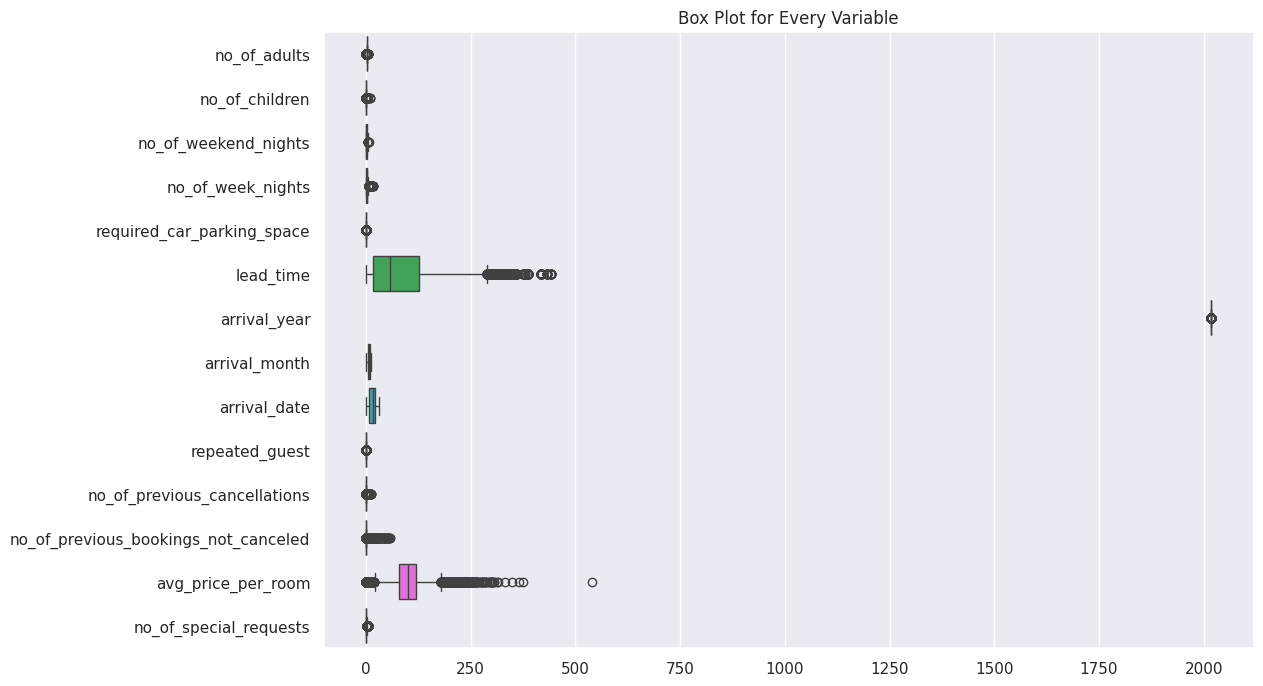

(36275, 19)


In [ ]:
plt.figure(figsize=(12, 8))
sns.set(style="darkgrid")
sns.boxplot(data=df, orient="h")
plt.title("Box Plot for Every Variable")
plt.show()
print(df.shape)

*Cancellation Rate vs Lead Time (Binned)*

- Cancellation rate increases with lead time.

/tmp/ipykernel_592/3002802365.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancel_rate = data.groupby("lead_time_bin")["booking_status"].apply(


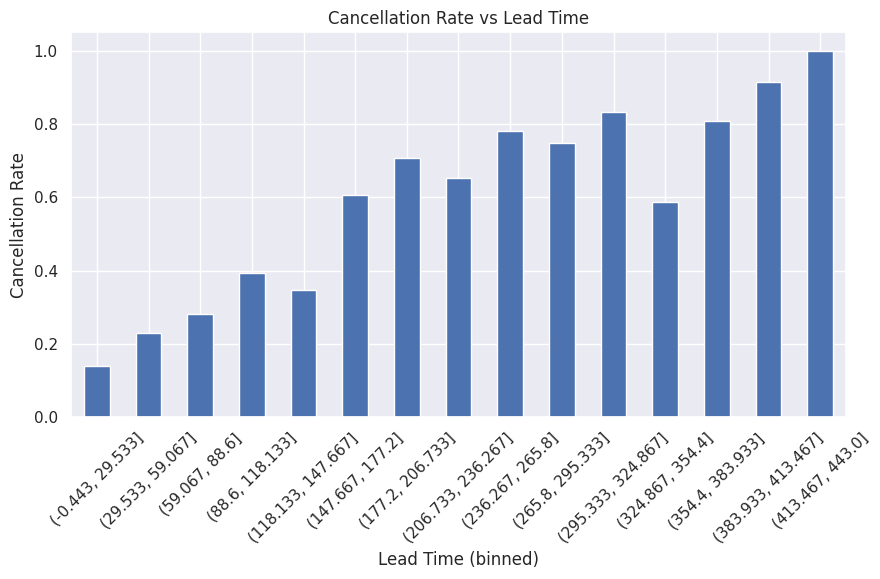

In [ ]:
data = df.copy()
# Create bins for lead time
data["lead_time_bin"] = pd.cut(data["lead_time"], bins=15)

# Calculate cancellation rate
cancel_rate = data.groupby("lead_time_bin")["booking_status"].apply(
    lambda x: (x == "Canceled").mean()
)

# Plot
plt.figure(figsize=(10,5))
cancel_rate.plot(kind="bar")
plt.title("Cancellation Rate vs Lead Time")
plt.xlabel("Lead Time (binned)")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

**Feature Engineering and Data Preparation**

In [3]:
df1 = df.copy()

# Drop irrelevant identifier column
df1.drop(columns='Booking_ID', inplace=True)

# Log-transformation
df1['lead_time_log'] = np.log1p(df1['lead_time'])
df1['price_log'] = np.log1p(df1['avg_price_per_room'])

# Map target variable
df1['booking_status'] = df1['booking_status'].map({
    'Canceled': 1,
    'Not_Canceled': 0
})

# Encode all categorical features using Label Encoding
for col in df1.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df1[col] = le.fit_transform(df1[col])

- Dropped Booking_ID since .

- Applied logarithmic transformation to lead_time and avg_price_per_room.

- Converted the target variable booking_status to binary numeric form (1 = canceled, 0 = not canceled).

- Encoded categorical features as numeric using Label Encoding.

In [ ]:
df1.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,lead_time_log,price_log
0,2,0,1,2,0,0,0,224,2017,10,2,3,0,0,0,65.00,0,0,5.416100,4.189655
1,2,0,2,3,3,0,0,5,2018,11,6,4,0,0,0,106.68,1,0,1.791759,4.679164
2,1,0,2,1,0,0,0,1,2018,2,28,4,0,0,0,60.00,0,1,0.693147,4.110874
3,2,0,0,2,0,0,0,211,2018,5,20,4,0,0,0,100.00,0,1,5.356586,4.615121
4,2,0,1,1,3,0,0,48,2018,4,11,4,0,0,0,94.50,0,1,3.891820,4.559126


**Train-Test Split and Class Balancing**

- Splitting dataset into training and testing sets (stratified to preserve class distribution)

- Using SMOTE to balance the training set

- Scaling features for linear models (Logistic Regression and SVM)

In [5]:
#Spliting the dataset
X = df1.drop(columns='booking_status')
Y = df1['booking_status']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42,stratify=Y)

In [6]:
#handling imbalanced data
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())

Before SMOTE: booking_status
0    19512
1     9508
Name: count, dtype: int64
After SMOTE: booking_status
0    19512
1    19512
Name: count, dtype: int64


In [7]:
# Scale for linear models (LogReg)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

**Model Training**

In [8]:
#Log Reg
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train_sm)

LogisticRegression(max_iter=1000)

In [9]:
#random Forest
rf = RandomForestClassifier()
rf.fit(X_train_sm, y_train_sm)


RandomForestClassifier()

In [10]:
#Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train_sm, y_train_sm)

DecisionTreeClassifier()

In [11]:
#XGBoost
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train_sm, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#SVM
svm = SVC(kernel='linear')
svm.fit(X_train_scaled, y_train_sm)


SVC(kernel='linear')

**Feature Importance & Final Dataset Preparation**

Random Forest Feature Importance

- Features like lead_time_log, market_segment_type, repeated_guest, and no_of_special_requests are highly important for predicting cancellations.

In [13]:
#rf feat imp
rf_importance = rf.feature_importances_

feat_imp_rf = pd.Series(rf_importance, index=X.columns)
feat_imp_rf = feat_imp_rf.sort_values(ascending=False)

print(feat_imp_rf)

lead_time_log                           0.188724
lead_time                               0.159380
no_of_special_requests                  0.136078
avg_price_per_room                      0.092476
price_log                               0.089893
arrival_month                           0.069863
arrival_date                            0.063687
market_segment_type                     0.050685
no_of_week_nights                       0.036490
no_of_weekend_nights                    0.029389
arrival_year                            0.019428
no_of_adults                            0.017556
type_of_meal_plan                       0.015915
room_type_reserved                      0.013296
required_car_parking_space              0.008262
no_of_children                          0.004489
repeated_guest                          0.002410
no_of_previous_bookings_not_canceled    0.001713
no_of_previous_cancellations            0.000267
dtype: float64


Decision Tree Feature Importance

In [12]:
#dt feat imp
dt_importance = dt.feature_importances_

feat_imp_dt = pd.Series(dt_importance, index=X.columns)
feat_imp_dt = feat_imp_dt.sort_values(ascending=False)

print(feat_imp_dt)

lead_time_log                           0.298503
no_of_special_requests                  0.119983
market_segment_type                     0.099403
price_log                               0.078064
arrival_month                           0.077878
arrival_date                            0.071732
avg_price_per_room                      0.063124
lead_time                               0.050960
no_of_week_nights                       0.038868
no_of_weekend_nights                    0.033714
no_of_adults                            0.021030
type_of_meal_plan                       0.013032
arrival_year                            0.011512
room_type_reserved                      0.010020
required_car_parking_space              0.007418
no_of_children                          0.002846
repeated_guest                          0.001520
no_of_previous_cancellations            0.000267
no_of_previous_bookings_not_canceled    0.000124
dtype: float64


XGBoost Feature Importance

In [15]:
#xgb feature imp
xgb_importance = xgb_model.feature_importances_

feat_imp_xgb = pd.Series(xgb_importance, index=X.columns)
feat_imp_xgb = feat_imp_xgb.sort_values(ascending=False)

print(feat_imp_xgb)

market_segment_type                     0.168135
no_of_special_requests                  0.153852
lead_time_log                           0.115006
required_car_parking_space              0.101206
lead_time                               0.079419
repeated_guest                          0.053155
arrival_year                            0.048337
arrival_month                           0.047447
no_of_adults                            0.039534
avg_price_per_room                      0.035840
no_of_weekend_nights                    0.031150
type_of_meal_plan                       0.028770
room_type_reserved                      0.026148
price_log                               0.022273
no_of_week_nights                       0.019983
arrival_date                            0.014566
no_of_children                          0.008923
no_of_previous_cancellations            0.006256
no_of_previous_bookings_not_canceled    0.000000
dtype: float32


Logistic Regression Feature Importance


In [ ]:
#logictic regression feature imp
feat_imp_lr = pd.Series(lr.coef_[0], index=X.columns)
feat_imp_lr = feat_imp_lr.sort_values(ascending=False)
print(feat_imp_lr)

lead_time                               1.000141
market_segment_type                     0.698371
avg_price_per_room                      0.517125
lead_time_log                           0.403446
price_log                               0.327467
arrival_year                            0.123360
type_of_meal_plan                       0.078688
no_of_previous_cancellations            0.048814
no_of_weekend_nights                    0.040427
arrival_date                            0.016269
no_of_week_nights                      -0.020358
room_type_reserved                     -0.078578
no_of_children                         -0.084375
no_of_previous_bookings_not_canceled   -0.093892
no_of_adults                           -0.132745
arrival_month                          -0.190805
required_car_parking_space             -0.282957
repeated_guest                         -0.314911
no_of_special_requests                 -1.144264
dtype: float64


SVM Feature Importance

In [16]:
#svm feature imp
svc_imp = svm.coef_[0]

svc_imp = pd.Series(svc_imp, index=X.columns)
svc_imp = svc_imp.sort_values(key=abs, ascending=False)

print(svc_imp.head)

NameError: name 'svm' is not defined

**Final Dataset Preparation for Modeling**

In [ ]:
#Creating the final dataset
df_final = df1.drop(columns=['lead_time','avg_price_per_room'])

In [ ]:
#Splitting the data
X = df_final.drop(columns='booking_status')
Y = df_final['booking_status']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2,random_state=42,stratify=Y)

In [ ]:
#Handling class imbalance
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [ ]:
#Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

- Dropped lead_time and avg_price_per_room since log-transformed versions are now included.

- Final dataset is ready for training models with balanced classes and scaled features for linear models.

***Hyperparameter Tuning and Model Re-training***

*Logistic Regression Hyperparameter Tuning*

In [ ]:
#Log Reg
#Parameter Grid
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

#Performing GridSearchCV
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    cv=5,
    scoring='f1'
)

grid_lr.fit(X_train_scaled, y_train_sm)

#Printing the best para
print(grid_lr.best_params_)

{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


- **C:** Controls how much the model avoids overfitting. Higher C → less regularization.  
- **penalty:** Type of regularization (e.g., 'l1' or 'l2') to prevent overfitting.  
- **solver:** Algorithm used to fit the model (e.g., 'lbfgs', 'liblinear').  
- **max_iter:** Maximum number of iterations allowed for the solver to converge.

- Using F1-score ensures the model balances precision and recall, which is important due to class imbalance.

- Best parameters found: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}

*Re-train Logistic Regression with Best Parameters*

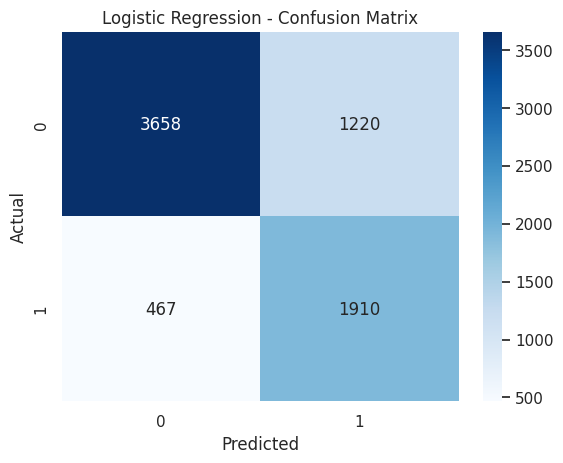

In [ ]:
#Log Reg
#{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
lr = LogisticRegression(max_iter=1000,C=10,penalty='l2',solver='lbfgs')
lr.fit(X_train_scaled, y_train_sm)

y_pred_log = lr.predict(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

*Re-train SVM with Best Parameters*

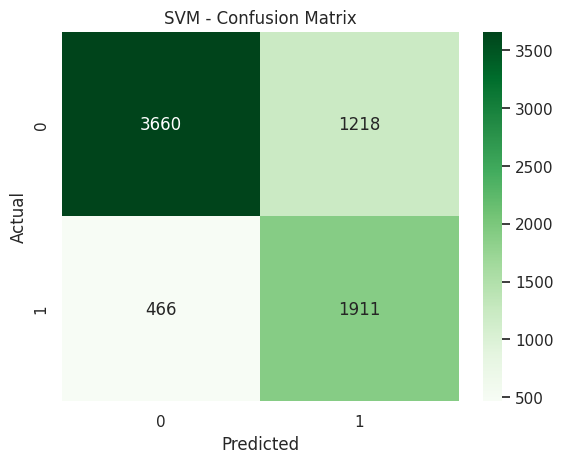

In [ ]:
#SVC

svm = SVC(kernel='linear',probability=True)
svm.fit(X_train_scaled, y_train_sm)

y_pred_svm = svm.predict(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('SVM - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

*Decision Tree Hyperparameter Tuning*

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

# Parameter grid
param_grid_dt = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    dt,
    param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_dt.fit(X_train_sm, y_train_sm)
#Printing the best para
print("Best Parameters for Decision Tree:", grid_dt.best_params_)

Best Parameters for Decision Tree: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


- **max_depth:** Maximum depth of the tree. Higher depth → more complex model (risk of overfitting).

- **min_samples_split:** Minimum samples required to split a node. Higher values prevent overfitting.

- **min_samples_leaf:** Minimum samples required at a leaf node. Helps smooth the model and improve generalization.

- **criterion:** Function to measure split quality.  
- gini → Gini impurity  
- entropy → Information gain  

- Best parameters found: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}

*Re-train Descision Tree with Best Parameters*

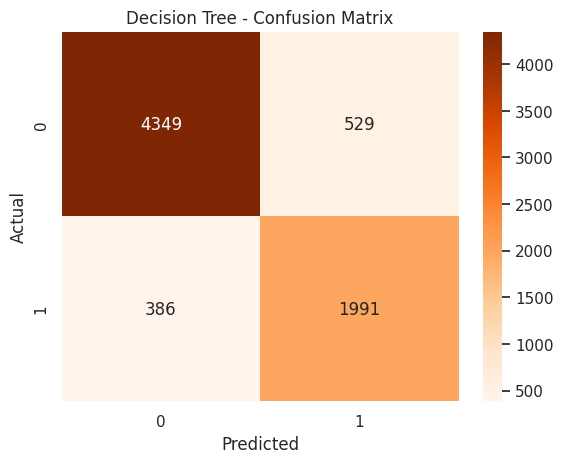

In [ ]:
#Decision tree
# {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}

dt = DecisionTreeClassifier(criterion='entropy',max_depth=15,min_samples_leaf=1,min_samples_split=2)
dt.fit(X_train_sm, y_train_sm)

y_pred_dt = dt.predict(X_test)

cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Decision Tree - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

*Random Forest Hyperparameter Tuning*

In [ ]:
rf = RandomForestClassifier()
#Parameter Grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train_sm, y_train_sm)
#Printing the best para
print(grid_rf.best_params_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


- **n_estimators:** Number of trees in the forest. More trees → better performance but higher computation.

- **max_depth:** Limits depth of each tree to prevent overfitting.

- **min_samples_split:** Minimum samples required to split a node.

- **min_samples_leaf:** Minimum samples at leaf nodes to improve generalization.

- Best parameters found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

*Re-train Random Forest with Best Parameters*

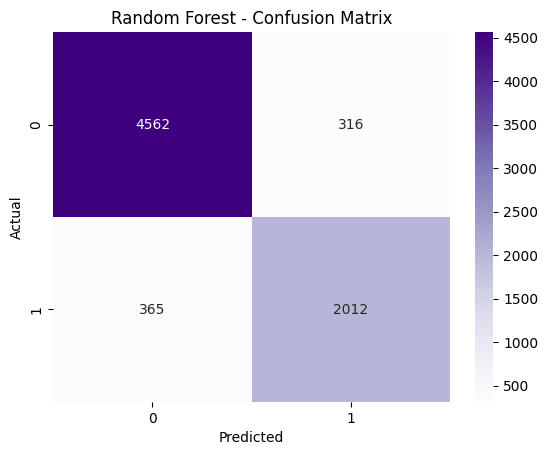

In [17]:
#Random Forest
#{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

rf = RandomForestClassifier(max_depth=None,min_samples_leaf=1,min_samples_split=2,n_estimators=200)
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

*XGBoost Hyperparameter Tuning*

In [ ]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
#Paramter Grid
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    xgb_model,
    param_grid_xgb,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_xgb.fit(X_train_sm, y_train_sm)
#Printing the best para
print(grid_xgb.best_params_)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:05:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


- **n_estimators:** Number of boosting rounds (trees). More trees → better learning but slower.

- **max_depth:** Maximum depth of each tree. Higher depth captures complex patterns but may overfit.

- **learning_rate:** Step size for updating weights. Lower values → slower but more accurate learning.

- **subsample:** Fraction of data used per tree. Lower values help reduce overfitting.

- Best parameters found: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

*Re-train XGBoost with Best Parameters*

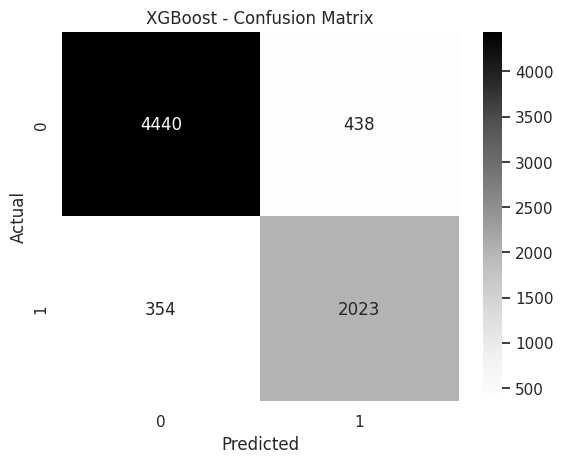

In [ ]:
#XGboost
#{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

xgb_model = xgb.XGBClassifier(learning_rate=0.1,max_depth=7,n_estimators=200,subsample=0.8)
xgb_model.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greys')
plt.title('XGBoost - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

***Model Performance Comparison***

- To evaluate and compare all trained models, multiple performance metrics are calculated, including Precision, Recall, F1-score, Accuracy, and ROC-AUC.

- Weighted averages are used for Precision, Recall, and F1-score to account for class imbalance and provide a balanced evaluation.

- A comparison table is created to summarize model performance across all metrics.

- Bar plots and heatmaps are used to visually compare models and identify performance differences more effectively.




Model Performance Table:

                     Precision  Recall  F1-score  Accuracy    AUC
Logistic Regression      0.796   0.767     0.774     0.767  0.854
SVM                      0.797   0.768     0.774     0.768  0.855
Decision Tree            0.876   0.874     0.875     0.874  0.925
Random Forest            0.902   0.902     0.902     0.902  0.958
XGBoost                  0.892   0.891     0.891     0.891  0.956


<Figure size 2500x600 with 0 Axes>

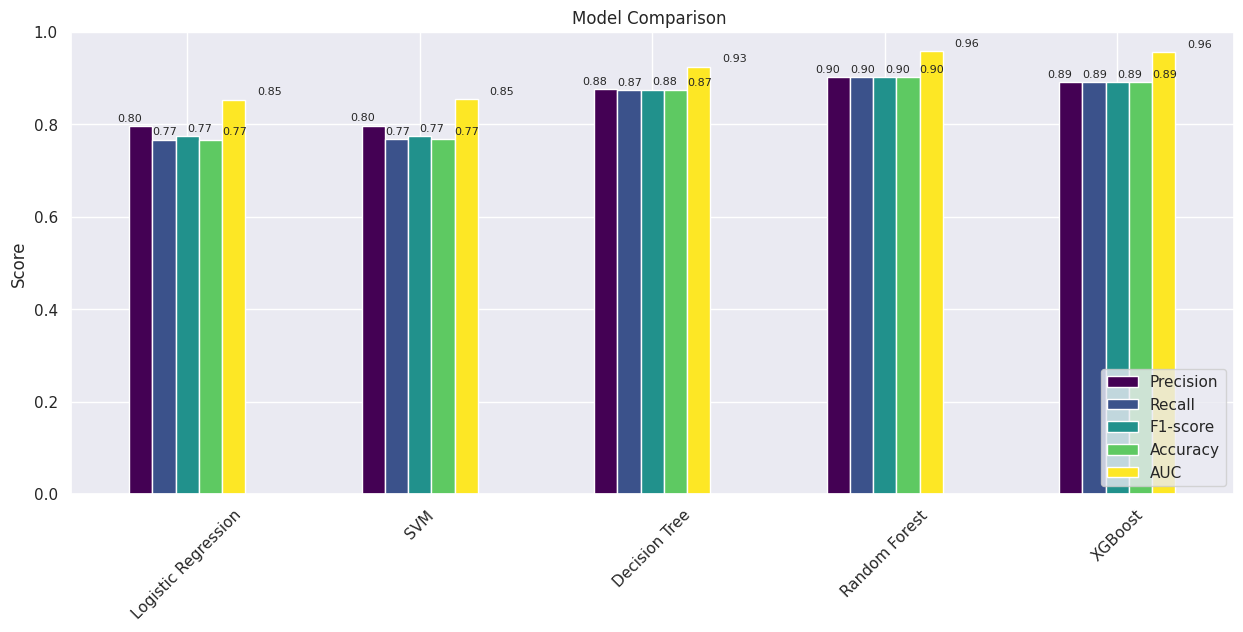

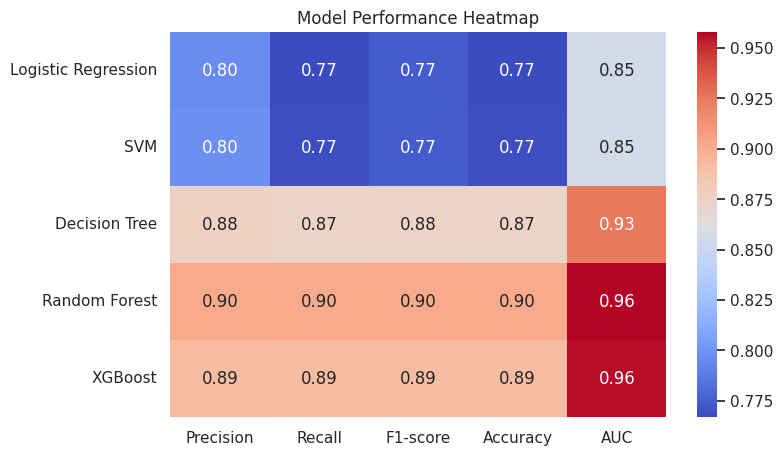


Best Models by Metric:

Precision: Random Forest (0.902)
Recall: Random Forest (0.902)
F1-score: Random Forest (0.902)
Accuracy: Random Forest (0.902)
AUC: Random Forest (0.958)

Final Model Selection:
Best model based on F1-score: Random Forest
Best model based on AUC: Random Forest


In [ ]:
# 1. METRICS CALCULATION
metrics_dict = {}

# Logistic Regression
metrics_dict['Logistic Regression'] = {
    'Precision': precision_score(y_test, y_pred_log, average='weighted'),
    'Recall': recall_score(y_test, y_pred_log, average='weighted'),
    'F1-score': f1_score(y_test, y_pred_log, average='weighted'),
    'Accuracy': accuracy_score(y_test, y_pred_log),
    'AUC': roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1])
}

# SVM
metrics_dict['SVM'] = {
    'Precision': precision_score(y_test, y_pred_svm, average='weighted'),
    'Recall': recall_score(y_test, y_pred_svm, average='weighted'),
    'F1-score': f1_score(y_test, y_pred_svm, average='weighted'),
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'AUC': roc_auc_score(y_test, svm.predict_proba(X_test_scaled)[:,1])
}

# Decision Tree
metrics_dict['Decision Tree'] = {
    'Precision': precision_score(y_test, y_pred_dt, average='weighted'),
    'Recall': recall_score(y_test, y_pred_dt, average='weighted'),
    'F1-score': f1_score(y_test, y_pred_dt, average='weighted'),
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'AUC': roc_auc_score(y_test, dt.predict_proba(X_test)[:,1])
}

# Random Forest
metrics_dict['Random Forest'] = {
    'Precision': precision_score(y_test, y_pred_rf, average='weighted'),
    'Recall': recall_score(y_test, y_pred_rf, average='weighted'),
    'F1-score': f1_score(y_test, y_pred_rf, average='weighted'),
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'AUC': roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
}

# XGBoost
metrics_dict['XGBoost'] = {
    'Precision': precision_score(y_test, y_pred_xgb, average='weighted'),
    'Recall': recall_score(y_test, y_pred_xgb, average='weighted'),
    'F1-score': f1_score(y_test, y_pred_xgb, average='weighted'),
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'AUC': roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])
}


# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_dict).T.round(3)
print("\nModel Performance Table:\n")
print(metrics_df)


# 2. BAR PLOT
plt.figure(figsize=(25,6))
metrics_df.plot(kind='bar', figsize=(15,6),colormap='viridis')

plt.title('Model Comparison ')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=45)

for i in range(len(metrics_df)):
    for j, val in enumerate(metrics_df.iloc[i]):
        plt.text(i + j*0.15 - 0.3, val + 0.01, f"{val:.2f}", fontsize=8)

plt.legend(loc='lower right')
plt.show()

# 3. HEATMAP
plt.figure(figsize=(8,5))
sns.heatmap(metrics_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Model Performance Heatmap")
plt.show()



# 4. BEST MODEL PER METRIC
print("\nBest Models by Metric:\n")

for metric in metrics_df.columns:
    best_model = metrics_df[metric].idxmax()
    best_score = metrics_df[metric].max()
    print(f"{metric}: {best_model} ({best_score:.3f})")



# 5. FINAL BEST MODEL
best_f1 = metrics_df['F1-score'].idxmax()
best_auc = metrics_df['AUC'].idxmax()

print("\nFinal Model Selection:")
print(f"Best model based on F1-score: {best_f1}")
print(f"Best model based on AUC: {best_auc}")

**Observations**

- Random Forest achieves the highest performance across all evaluation metrics, with an F1-score of 0.903 and AUC of 0.959, indicating excellent predictive capability and class separation.

**Final Model Selection**

The best model is selected based on:

- **F1-score:** Ensures a balance between false positives and false negatives  
- **AUC score:** Measures overall classification performance

***Random Forest*** is selected as the best model as it achieves the highest F1-score and AUC, making it the most reliable model for predicting hotel booking cancellations.


**ROC-AUC Curve Comparison**

- ROC-AUC curves are plotted to compare the classification performance of all models across different thresholds.

- The curve shows the trade-off between True Positive Rate (Recall) and False Positive Rate.


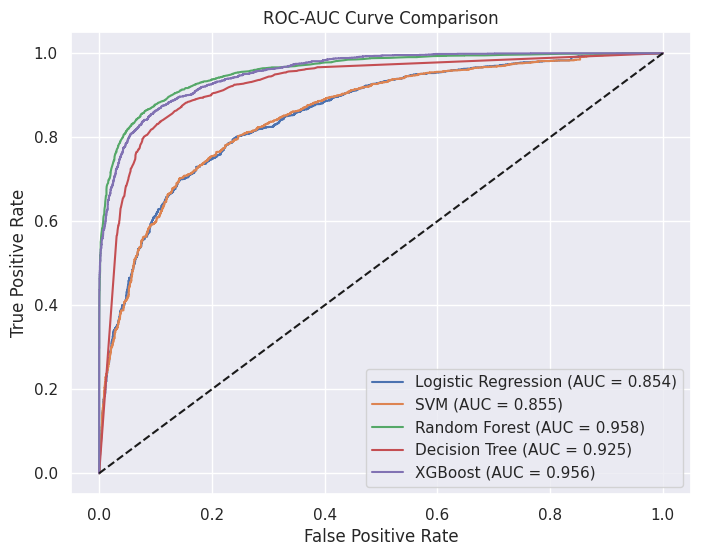

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# FUNCTION
def plot_roc(model, X_test, y_test, model_name):
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")


# PLOT
plt.figure(figsize=(8,6))

# Scaled models
plot_roc(lr, X_test_scaled, y_test, "Logistic Regression")
plot_roc(svm, X_test_scaled, y_test, "SVM")

# Non-scaled models
plot_roc(rf, X_test, y_test, "Random Forest")
plot_roc(dt, X_test, y_test, "Decision Tree")
plot_roc(xgb_model, X_test, y_test, "XGBoost")

# Diagonal line
plt.plot([0,1], [0,1], 'k--')

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve Comparison")
plt.legend()
plt.show()

**Risk Scoring and Customer Segmentation**

- Predicted probabilities from the model are used to assign a cancellation risk score to each booking.

- Bookings are categorized into three risk levels:
  - Low Risk (0 – 0.4)
  - Medium Risk (0.4 – 0.7)
  - High Risk (0.7 – 1.0)



In [ ]:
# Risk Scoring
# Using Logistic Regression as example,can be replaced by any model
X_eval = X_test
y_risk_prob = rf.predict_proba(X_eval)[:,1]

risk_df = X_test.copy()
risk_df["Cancellation_Probability"] = y_risk_prob
risk_df["Risk_Category"] = pd.cut(
    risk_df["Cancellation_Probability"],
    bins=[0,0.4,0.7,1],
    labels=["Low","Medium","High"]
)
print("Sample Risk Scoring Table:\n")
display(risk_df.head())

Sample Risk Scoring Table:



,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,no_of_special_requests,lead_time_log,price_log,Cancellation_Probability,Risk_Category
2494,2,0,0,4,0,0,3,2018,9,7,4,0,0,0,0,4.510860,5.013298,0.830000,High
5419,2,0,2,0,0,0,0,2018,9,11,3,0,0,0,0,3.891820,4.460144,0.100000,Low
10483,2,0,1,1,0,0,0,2017,9,26,4,0,0,0,1,3.583519,5.303305,0.325000,Low
36097,1,0,0,1,0,0,0,2018,5,25,4,0,0,0,0,3.526361,4.699571,0.523864,Medium
34626,1,0,0,1,1,0,0,2017,12,10,4,0,0,0,0,1.945910,0.000000,0.005000,Low


**Feature Importance – Random Forest**

- Feature importance helps identify which variables have the most influence on predicting cancellations.

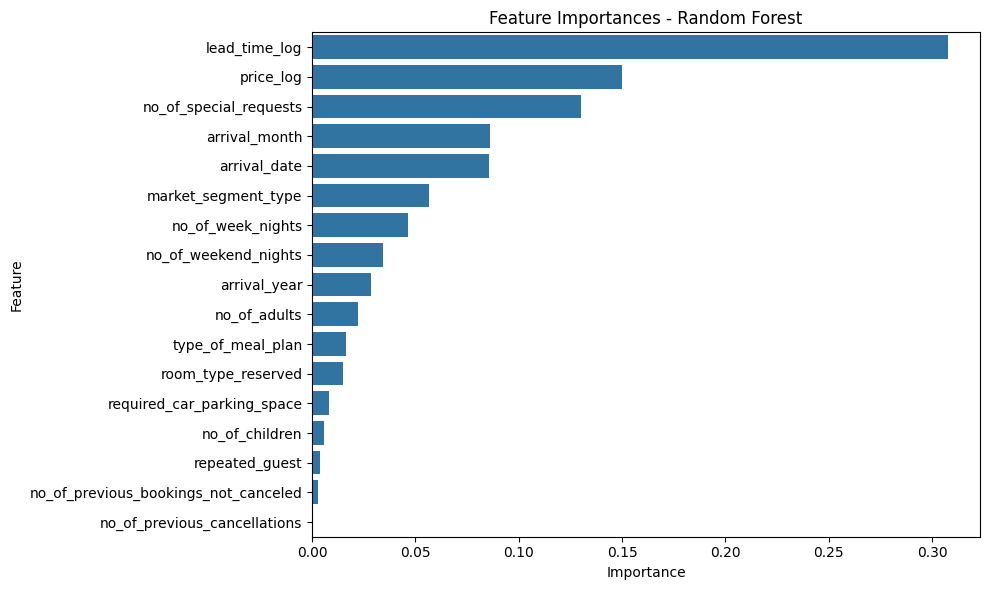

In [ ]:
#feature imp for random forest
feature_importances = rf.feature_importances_

# Create a DataFrame for visualization
features = X_train.columns  # columns used in training
importance_df = pd.DataFrame({
    'feature': features,
    'importance': feature_importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title("Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Predicting New Booking Outcomes**

- A sample booking is created with new input values to test the trained model.

- The model predicts:
  - Whether the booking will be canceled or not  
  - The probability (risk percentage) of cancellation  

In [ ]:
# Predicting with unknown values
new_booking = pd.DataFrame({
    'no_of_adults': [2],
    'no_of_children': [1],
    'no_of_weekend_nights': [2],
    'no_of_week_nights': [3],
    'required_car_parking_space': [0],
    'arrival_year': [2026],
    'arrival_month': [3],
    'arrival_date': [20],
    'repeated_guest': [0],
    'no_of_previous_cancellations': [0],
    'no_of_previous_bookings_not_canceled': [0],
    'no_of_special_requests': [1],
    'room_type_reserved': [3],
    'type_of_meal_plan': [0],
    'market_segment_type': [0],
    'lead_time_log': [np.log1p(30)],
    'price_log': [np.log1p(120)]
})

# Make sure column order matches training
new_booking = new_booking[X_train.columns]

# Predict
pred_class = rf.predict(new_booking)[0]
pred_prob  = rf.predict_proba(new_booking)[:,1][0]

print("Predicted class:", "Canceled" if pred_class==1 else "Not Canceled")
print("Predicted risk:", f"{int(pred_prob*100)}%")

Predicted class: Not Canceled
Predicted risk: 28%


In [ ]:
new_booking = pd.DataFrame({
    'no_of_adults': [2],
    'no_of_children': [0],
    'no_of_weekend_nights': [3],
    'no_of_week_nights': [5],
    'type_of_meal_plan': [0],
    'required_car_parking_space': [0],
    'room_type_reserved': [3],
    'arrival_year': [2026],
    'arrival_month': [6],
    'arrival_date': [15],
    'market_segment_type': [0],
    'repeated_guest': [0],
    'no_of_previous_cancellations': [0],
    'no_of_previous_bookings_not_canceled': [0],
    'no_of_special_requests': [0],
    'lead_time_log': [np.log1p(120)],
    'price_log': [np.log1p(200)]
})

# Make sure column order matches training
new_booking = new_booking[X_train.columns]

# Predict
pred_class = rf.predict(new_booking)[0]
pred_prob = rf.predict_proba(new_booking)[:,1][0]

print("Predicted class:", "Canceled" if pred_class==1 else "Not Canceled")
print("Predicted risk:", f"{pred_prob:.2f} ({int(pred_prob*100)}%)")

Predicted class: Canceled
Predicted risk: 0.65 (65%)


In [18]:
#Downloading the trained model
joblib.dump(rf, "HotelCan_Model.pkl")

['HotelCan_Model.pkl']